# Encoder Pipeline — Bi-Planar DRR → Multi-Scale 3D Features

Shared encoder front-end for the **3D U-Net vs V-Net** comparison (both decoders consume the
same features; only the decoder differs). Built by adapting Lai's reference pipeline
(`references/04_Finetunning.ipynb`, `references/07_feature_fusion.ipynb`).

**Goal:** capture *fine-grain local context* (fracture morphology — cortical breaks, displaced /
comminuted fragments) **and** *global shape* (overall knee geometry), for both healthy and
fractured knees.

**This notebook produces** multi-scale **3D feature maps** ready to plug into a U-Net or V-Net
decoder, validated by a forward-pass smoke test. It stops *before* the decoder / full supervised
training.

### Pipeline
`DRRs (ap+lat, 256² .npy) → ConvNeXtV2 multi-scale encoder → hybrid bi-planar fusion → 2D→3D lift → [64,128,256,512]-channel 3D features`

### Key choices (locked with supervisor input)
- **Baseline, designed well** — no fracture-specific modules yet (custom fracture-aware arch stays a *conditional* stretch goal).
- **FCMAE masked-region pretrain (+ optional cross-view completion) → fine-tunable encoder** (replaces
  SimCLR — see §2). FCMAE reconstructs masked patches, forcing *local geometry* modelling with **no**
  invariance pressure on the fracture signal; labels are **monitoring-only** so the stage stays
  label-free and pretrained-once-globally. Cross-view completion adds a 3D-consistency pressure the
  downstream orthogonal lift relies on.
- **Target = binary bone occupancy** (Lai-faithful); GT binarization is *documented* here, used by the decoder stage later.
- **Hybrid fusion**: full cross-attention at coarse stages (global shape); lightweight conv fusion at fine stages (local detail, avoids 4096² attention at 256²).

### Fixes / changes vs the reference (verified)
1. **SimCLR retired.** Its instance-discrimination + augmentation-invariance objective teaches the
   encoder to treat defect-scale local variation as nuisance (the opposite of this project's goal), and
   NT-Xent is not an interpretable quality signal. Replaced with FCMAE (§2), the pretext task
   ConvNeXtV2 was co-designed for. Quality signals are now **M-6** (representation probe) and **Gate G4**
   (downstream), not a contrastive loss value.
2. Reference loaded a `num_classes=0` checkpoint into a `features_only` encoder (keys mismatch). Here the
   FCMAE encoder wraps the *same* `features_only` backbone and exports a bare `state_dict`, so transfer
   to the fusion model is exact (`strict` load, missing=0).
3. Data adapted to this project: views `la/pa`→`ap/lat`, `.png`/PIL → `.npy`/`np.load`, 224→native 256,
   healthy/fractured-aware sampling.

In [1]:
import os, math, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import timm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- resolve project root (works whether run from notebooks/modeling/ or project root) ---
def find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed").exists() and (cand / "references").exists():
            return cand
    raise FileNotFoundError("Could not locate project root (expected data/processed + references).")

ROOT = find_root(Path.cwd())
DATA = ROOT / "data"
NORMAL_DRR_DIR = DATA / "interim" / "DRRs"                       # normal DRRs
AUG_DRR_DIR    = DATA / "processed" / "augmented_DRRs"           # augmented DRRs
PREDRR_DIR     = DATA / "interim" / "predrr"                     # 3D GT CT (deferred)
MODELS_DIR     = ROOT / "models"; MODELS_DIR.mkdir(exist_ok=True)

# --- config ---
BACKBONE      = "convnextv2_tiny"
IMG_SIZE      = 256
OUT_CHANNELS  = [64, 128, 256, 512]
FUSION_TYPES  = ["local", "local", "attn", "attn"]   # fine→coarse; the hybrid local/global design
DEPTH         = 16                                   # 2D→3D lift depth (final depth set with decoder)
FREEZE_ENCODER = False                               # keep fine-tunable
PRETRAINED    = True                                 # ImageNet FCMAE ConvNeXtV2 weights; falls back offline

# --- FCMAE pretraining config (replaces SimCLR; see §2) ------------------------------------------
# Masked-region FCMAE + optional cross-view completion. Labels are MONITORING-ONLY (no gradient, no
# sampling) — the stage stays label-free so it can be pretrained once globally and reused across folds.
PATCH        = 32                 # px per mask patch  → 8×8 mask grid at stride-32
MASK_GRID    = IMG_SIZE // PATCH  # 8
MASK_RATIO   = 0.6                # fraction of the ELIGIBLE set masked (worth a small sweep {0.5,0.6,0.7})
OCC_ELIGIBLE = 0.05               # min structure occupancy for a patch to be eligible for masking
BG_QUOTA     = 0.15               # fraction of E made of uniformly-sampled pure-background patches
SIGMA_FLOOR  = 0.01               # per-patch target-σ floor (normalization blow-up guard, M-4)
MIN_ELIGIBLE = 8                  # degenerate-instance guard: skip images with |E| < this
STRUCT_WEIGHT = 2.0               # ×weight for in-structure pixels within masked patches (§2.4)
MONITOR_FRAC = 0.10               # instance-level held-out monitor fraction (L-4), fragmentation-stratified
LAMBDA_XVIEW = 1.0               # weight of the cross-view term in P2 (L = L_FCMAE + λ·L_crossview)
XVIEW_SLACK  = 1                  # row-wise cross-attention: ± this many grid-rows of slack (§3.2)
# defect-preserving augmentation only (§2.5). FORBIDDEN (never add): cutout/random-erasing (fabricates
# fake fragments), aggressive crops (delete real fragments), strong elastic (fabricates displacement).
AUG_HFLIP    = False              # left/right knees are mirror-related; OFF to avoid confounding laterality
AUG_ROT_DEG  = 8.0                # ± small rotation
AUG_TRANS    = 0.05               # ± translate as fraction of IMG_SIZE (structure mask moves identically)
AUG_GAMMA    = (0.85, 1.15)       # mild intensity gamma jitter (capture variation)
# smoke-scale run knobs (the full curriculum runs on the HPC twin)
RUN_P1, RUN_P2 = True, True
P1_STEPS, P2_STEPS, PRE_BS = 12, 12, 2

print("root:", ROOT)
print("device:", device, "| torch", torch.__version__, "| timm", timm.__version__)

root: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject
device: cpu | torch 2.10.0+cpu | timm 1.0.27


In [2]:
def make_backbone(pretrained=PRETRAINED):
    '''features_only ConvNeXtV2 returning 4 multi-scale maps. Robust to offline (no weights).'''
    try:
        return timm.create_model(BACKBONE, pretrained=pretrained, features_only=True)
    except Exception as e:
        print(f"[warn] pretrained fetch failed ({type(e).__name__}); using random init. {e}")
        return timm.create_model(BACKBONE, pretrained=False, features_only=True)

_probe = make_backbone(pretrained=False)
FEAT_DIMS = [f["num_chs"] for f in _probe.feature_info]
del _probe
print("multi-scale feature dims:", FEAT_DIMS)   # [96, 192, 384, 768]

multi-scale feature dims: [96, 192, 384, 768]


## 1. Dataset — normal + augmented DRRs

DRRs are `256×256 float32 [0,1]` `.npy` files. We index from the metadata CSVs (not `os.walk`):
- **Augmented:** `augmentation_variants_metadata.csv` — `ap_npy`/`lat_npy` are relative to `augmented_DRRs/`.
- **Normal:** `drr_generation_metadata.csv` — its `npy_path` is an HPC absolute path, so we **reconstruct local paths** from `dataset/case/side/view`.

Two datasets: `PairedDRRDataset` (returns `ap,lat` + metadata, for fusion/feature extraction) and
`SimCLRDRRDataset` (single images, two augmented views each, for contrastive pretraining).
Splits are **case-level** and **stratified** by healthy/fractured to avoid leakage.

In [3]:
def load_drr(path) -> torch.Tensor:
    '''npy 256x256 float32 [0,1] -> tensor [3,H,W] in [0,1] (1ch replicated to 3 for ConvNeXtV2).'''
    arr = np.load(path).astype(np.float32)
    t = torch.from_numpy(arr)
    if t.ndim == 2:
        t = t.unsqueeze(0)
    return t.repeat(3, 1, 1) if t.shape[0] == 1 else t

NORMALIZE = T.Normalize(mean=[0.5] * 3, std=[0.5] * 3)

# deterministic transform for paired/feature extraction (keep native 256)
def paired_tf(t):
    return NORMALIZE(t)

# stochastic two-view augmentation for SimCLR (operates on tensors)
simclr_aug = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), antialias=True),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.5),
    NORMALIZE,
])

def build_paired_index() -> pd.DataFrame:
    '''One row per (case, side, variant) with absolute ap/lat paths + metadata.'''
    rows = []
    # normal DRRs (variant = 'normal'); reconstruct local paths from columns
    nmeta = pd.read_csv(NORMAL_DRR_DIR / "drr_generation_metadata.csv")
    for (ds, case, side), _ in nmeta.groupby(["dataset", "case", "side"]):
        ap = NORMAL_DRR_DIR / ds / case / side / "ap.npy"
        lat = NORMAL_DRR_DIR / ds / case / side / "lat.npy"
        if ap.exists() and lat.exists():
            rows.append(dict(dataset=ds, case=case, side=side, variant="normal",
                             geometric=False, ap=str(ap), lat=str(lat)))
    # augmented DRRs
    ameta = pd.read_csv(AUG_DRR_DIR / "augmentation_variants_metadata.csv")
    for r in ameta.itertuples(index=False):
        ap = AUG_DRR_DIR / r.ap_npy; lat = AUG_DRR_DIR / r.lat_npy
        if ap.exists() and lat.exists():
            rows.append(dict(dataset=r.dataset, case=r.case, side=r.side, variant=r.variant,
                             geometric=bool(r.geometric), ap=str(ap), lat=str(lat)))
    return pd.DataFrame(rows)

paired_index = build_paired_index()
print("paired rows:", len(paired_index))
print(paired_index.groupby("dataset")["case"].nunique().to_dict(), "cases per dataset")
print(paired_index["dataset"].value_counts().to_dict(), "pairs per dataset")
paired_index.head(3)

paired rows: 1698
{'fractured': 13, 'healthy': 30} cases per dataset
{'healthy': 1388, 'fractured': 310} pairs per dataset


,dataset,case,side,variant,geometric,ap,lat
0,fractured,Case11,right,normal,False,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
1,fractured,Case12,right,normal,False,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...
2,fractured,Case13,right,normal,False,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...,C:\Users\Chan Zheng Shao\OneDrive\Desktop\Gith...


## 1b. Bone-focused DRR mask — fracture-safety gate (Step 0)

The L0 features show vertical stripes where the encoder fires on the DRR's **soft-tissue skin→air
silhouette** (a probe traced the brightest feature columns back to the leg's outer edge). The fix is a
**bone-focused mask**: keep bone + a feathered margin, suppress the surrounding soft tissue — which
also aligns the input with the binary bone-occupancy target.

Because fracture preservation is the project's crux, this **gates** on a safety check *before* the mask
is wired into `load_drr`: the **suppressed residual** `arr*(1-soft)` must be soft-tissue **only** — no
bone-level pixels (`resid_bone_px ≈ 0`) for any Ruikar fractured view, so no displaced/comminuted
fragment is ever clipped. The four-panel (input / mask / output / residual) lets you eyeball it. The
mask is fracture-safe by default (`BONE_MIN_AREA=0`, no distance limit) — DRRs are already speck-free
(specks were removed in 3D at predrr).

Fracture-safety gate: 620 views | rows with bone-level leak = 0 (must be 0) | worst resid_bone_px = 0
  case  side view  resid_bone_px  resid_max
 Case3  left  lat              0     0.3708
 Case5 right  lat              0     0.3632
 Case5 right  lat              0     0.3522
Case13 right  lat              0     0.3516
Case13 right  lat              0     0.3510
 Case1  left  lat              0     0.3470
 Case1  left  lat              0     0.3470
 Case1  left  lat              0     0.3461
 Case3  left  lat              0     0.3450
 Case1  left  lat              0     0.3448
 Case1  left  lat              0     0.3448
 Case3  left  lat              0     0.3447
 Case5 right  lat              0     0.3439
 Case3  left  lat              0     0.3439
 Case5 right  lat              0     0.3426
 Case3  left  lat              0     0.3388
 Case5 right  lat              0     0.3388
 Case3  left  lat              0     0.3373
 Case3  left  lat              0     0.3373
Case13 right  lat 

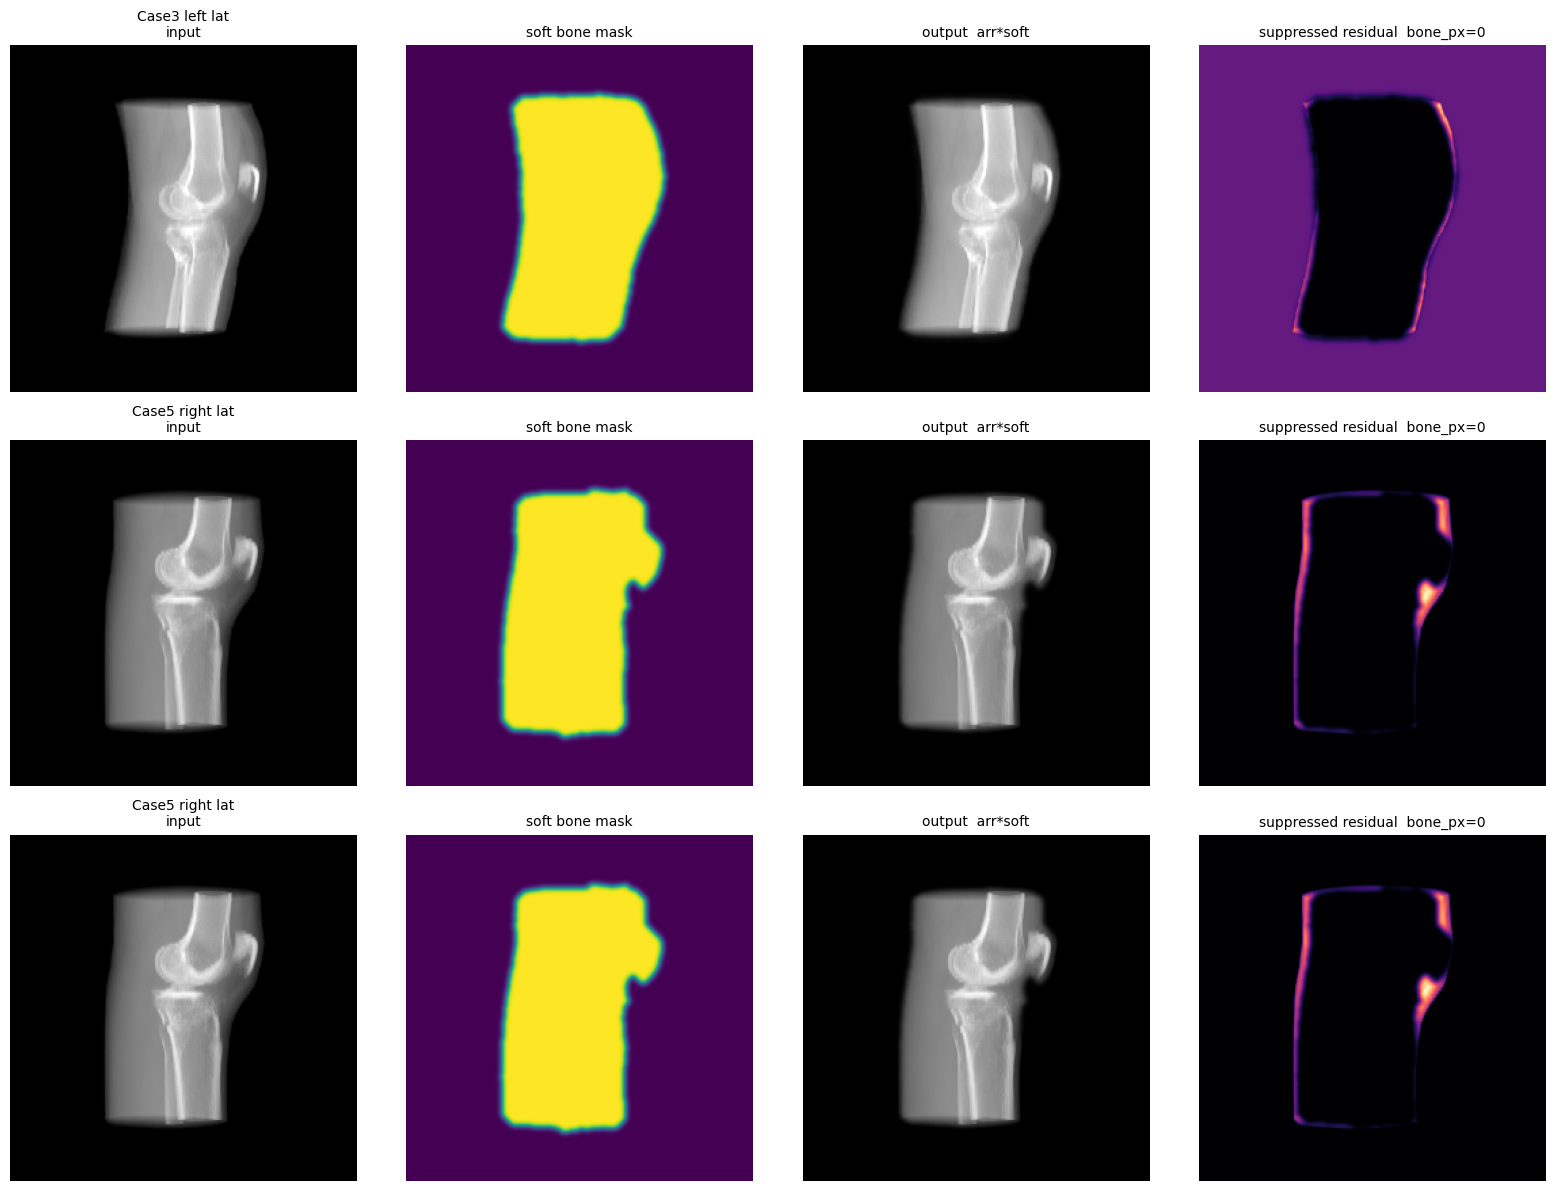

In [4]:
# --- Bone-focused DRR mask + Step-0 fracture-safety gate -----------------------------------------
# The encoder fires on the soft-tissue skin->air silhouette (the vertical stripes in the L0 features).
# A bone-focused mask suppresses that silhouette while keeping bone(+margin). Before wiring it into
# load_drr (next step), PROVE it never eats fracture energy: the suppressed residual arr*(1-soft) must
# be soft-tissue ONLY (no bone-level pixels) for every Ruikar fractured view.
import scipy.ndimage as ndi

BONE_MASK        = True   # A/B toggle vs the unmasked baseline (wired into load_drr in the next step)
BONE_THR         = 0.40   # [0,1] DRR intensity for "bone-ish"
BONE_MIN_AREA    = 0      # FRACTURE-SAFE: keep ALL bone-level components (DRRs are already speck-free)
BONE_MARGIN_PX   = 6      # dilate to keep cortical edge + cushion
BONE_FEATHER_SIG = 2.0    # px; feather so the mask edge is a gradient, not a new step

def _soft_bone_mask(arr2d):
    """HxW float32 [0,1], bg=0 -> [0,1] feathered bone mask. No distance limit so a displaced
    fragment survives even when far from the main bone. 2D bone-level analogue of predrr's
    body_envelope_mask()."""
    bone = arr2d > BONE_THR
    if BONE_MIN_AREA > 0:
        lbl, n = ndi.label(bone)
        if n:
            sizes = ndi.sum(np.ones_like(lbl), lbl, range(1, n + 1))
            bone = np.isin(lbl, 1 + np.where(sizes >= BONE_MIN_AREA)[0])
    bone = ndi.binary_fill_holes(bone)
    bone = ndi.binary_dilation(bone, iterations=BONE_MARGIN_PX)
    return np.clip(ndi.gaussian_filter(bone.astype(np.float32), BONE_FEATHER_SIG), 0, 1)

def bone_mask_drr(arr2d):
    """Keep bone(+margin), suppress the soft-tissue skin silhouette the encoder fires on."""
    return (arr2d * _soft_bone_mask(arr2d)).astype(np.float32)

# --- fracture-safety gate over every fractured view ---
frac = paired_index[paired_index.dataset == "fractured"]
_rows = []
for r in frac.itertuples(index=False):
    for view, p in [("ap", r.ap), ("lat", r.lat)]:
        arr = np.load(p).astype(np.float32)
        soft = _soft_bone_mask(arr); resid = arr * (1 - soft)
        _rows.append(dict(case=r.case, side=r.side, view=view,
                          resid_bone_px=int((resid > BONE_THR).sum()),
                          resid_max=round(float(resid.max()), 4)))
gate = pd.DataFrame(_rows).sort_values("resid_max", ascending=False).reset_index(drop=True)
leak = int((gate.resid_bone_px > 0).sum())
print(f"Fracture-safety gate: {len(gate)} views | rows with bone-level leak = {leak} "
      f"(must be 0) | worst resid_bone_px = {int(gate.resid_bone_px.max())}")
print(gate.to_string(index=False))

# four-panel eyeball for the 3 views where the mask suppresses the most (highest residual)
fig, axes = plt.subplots(3, 4, figsize=(16, 12), squeeze=False)
for i in range(3):
    row = gate.iloc[i]; rr = frac[(frac.case == row["case"]) & (frac.side == row["side"])].iloc[0]
    arr = np.load(rr.ap if row["view"] == "ap" else rr.lat).astype(np.float32)
    soft = _soft_bone_mask(arr); out = arr * soft; resid = arr * (1 - soft)
    panels = [(arr,  f"{row['case']} {row['side']} {row['view']}\ninput", 'gray'),
              (soft, "soft bone mask", 'viridis'),
              (out,  "output  arr*soft", 'gray'),
              (resid, f"suppressed residual  bone_px={int((resid > BONE_THR).sum())}", 'magma')]
    for ax, (img, ttl, cm) in zip(axes[i], panels):
        ax.imshow(img, cmap=cm); ax.set_title(ttl, fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

In [5]:
class PairedDRRDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=paired_tf):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        ap = self.transform(load_drr(r.ap)); lat = self.transform(load_drr(r.lat))
        return {"ap": ap, "lat": lat, "dataset": r.dataset, "case": r.case,
                "side": r.side, "variant": r.variant, "geometric": bool(r.geometric)}

class SimCLRDRRDataset(Dataset):
    '''Every ap and lat image is an anchor; returns two stochastic views.'''
    def __init__(self, df: pd.DataFrame, aug=simclr_aug):
        recs = []
        for r in df.itertuples(index=False):
            recs.append((r.ap, r.dataset)); recs.append((r.lat, r.dataset))
        self.recs = recs; self.aug = aug
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        path, ds = self.recs[i]
        base = load_drr(path)
        return self.aug(base), self.aug(base), ds

# --- case-level stratified split (all variants of a knee stay together) ---
def case_split(df, val_frac=0.2, seed=SEED):
    rng = random.Random(seed); val_keys = set()
    for ds, g in df.groupby("dataset"):
        keys = sorted(g.apply(lambda r: (r["case"], r["side"]), axis=1).unique().tolist())
        rng.shuffle(keys)
        n_val = max(1, int(round(len(keys) * val_frac)))
        val_keys.update((ds, k[0], k[1]) for k in keys[:n_val])
    is_val = df.apply(lambda r: (r["dataset"], r["case"], r["side"]) in val_keys, axis=1)
    return df[~is_val].copy(), df[is_val].copy()

train_df, val_df = case_split(paired_index)
print("train pairs:", len(train_df), "| val pairs:", len(val_df))
print("train cases:", train_df.groupby("dataset")["case"].nunique().to_dict(),
      "| val cases:", val_df.groupby("dataset")["case"].nunique().to_dict())

# --- weighted sampler: oversample fractured (14) vs healthy (58) knees ---
def balanced_sampler(df):
    counts = df["dataset"].value_counts().to_dict()
    w = df["dataset"].map(lambda d: 1.0 / counts[d]).to_numpy()
    return WeightedRandomSampler(weights=torch.as_tensor(w, dtype=torch.double),
                                 num_samples=len(df), replacement=True)

train pairs: 1338 | val pairs: 360
train cases: {'fractured': 10, 'healthy': 27} | val cases: {'fractured': 3, 'healthy': 9}


## 2. FCMAE masked-region pretraining (+ cross-view) — replaces SimCLR

The backbone is adapted to projection-image statistics with **FCMAE** (fully-convolutional masked
autoencoding) — the pretext task ConvNeXtV2 was co-designed for — instead of SimCLR. FCMAE reconstructs
masked patches, which forces the encoder to model **local geometry** (fracture morphology), needs no
negatives or large batches, and applies **no invariance pressure** to the fragmentation/displacement
signal the project must preserve. Two stages, run as a curriculum:

- **Stage P1 — FCMAE only**, from the ImageNet-FCMAE ConvNeXtV2 checkpoint, to plateau.
- **Stage P2 — joint FCMAE + cross-view completion**, initialized from P1. The AP/LAT pair is free
  supervision: each view must be predictable from the other, which pressures **3D-consistent** features
  (what the §3 orthogonal lift assumes). P1 and P2 are exported as **separate** checkpoints; Gate G4
  decides which (if any) ships.

**Design rules baked in here:**
1. **Label-free.** No cohort tag / GT / fold membership touches the gradient or the sampler. Labels are
   used for **monitoring only** (M-3/M-6, eval-side). This is what lets the stage be pretrained once,
   globally, and reused across all folds.
2. **Reconstruct structure, not background.** Masking is restricted to the safety-gated **intensity**
   structure mask (`_soft_bone_mask`, §1b) plus a small background quota — the images are mostly empty.
3. **No defect-fabricating augmentation.** Cutout/erasing/aggressive-crop/strong-elastic are forbidden
   (§2.5); the masking itself provides the task difficulty.
4. **The frozen contract is sacred.** The decoder + all pretext heads are **discarded** at export; only
   the encoder `state_dict` survives, and the §4 per-axis-variance + axis-alignment guards must still pass.

> **Cross-validation note.** Because the stage is label-free it is pretrained **once on the gradient
> split of ALL knees** (minus the held-out monitor set, L-4) and reused across every fold. Only
> *representation* exposure to test *images* remains — the standard low-data concession, unchanged from
> the SimCLR era. The **monitor set** (≈10% of instances, both views, stratified by a label-free
> fragmentation proxy) is excluded from pretraining gradients so the validation curves in §5 are real.

Below is a short **CPU smoke run** (few steps) proving the loop executes and the loss falls; the full
curriculum (100–400 epochs, early-stop on the monitor loss) runs on the HPC GPU twin.

In [6]:
# ============================ §2.0  Label-free monitor split (L-4) ============================
# Hold out ~MONITOR_FRAC of INSTANCES (both views together) from all pretraining gradients, so the §5
# validation curves are real. The split is stratified by a LABEL-FREE fragmentation proxy — the
# connected-component count of the intensity structure mask — NOT by the standard/irregular cohort
# label (using the label to build the split would leak it, L-2/L-4). Written to disk like the fold
# lists so the split is reproducible.

def fragmentation_proxy(ap_path):
    """Label-free fragmentation proxy: #connected components of the intensity bone mask (image-derived,
    no annotation). Higher ≈ more displaced/comminuted structure."""
    arr = np.load(ap_path).astype(np.float32)
    _, n = ndi.label(_soft_bone_mask(arr) > 0.5)
    return int(n)

_inst = (paired_index.groupby(["dataset", "case", "side"])
         .agg(ap=("ap", "first"), dataset_tag=("dataset", "first"))
         .reset_index())
_inst["frag"] = _inst["ap"].map(fragmentation_proxy)

# stratified ~MONITOR_FRAC hold-out across fragmentation terciles (label-free strata)
_rng = np.random.default_rng(SEED)
_inst["bin"] = pd.qcut(_inst["frag"].rank(method="first"), q=min(3, len(_inst)), labels=False)
_mon_idx = set()
for _b, g in _inst.groupby("bin"):
    k = max(1, int(round(MONITOR_FRAC * len(g))))
    _mon_idx.update(_rng.choice(g.index.to_numpy(), size=min(k, len(g)), replace=False).tolist())
_inst["role"] = np.where(_inst.index.isin(_mon_idx), "monitor", "gradient")

MONITOR_SPLIT_CSV = MODELS_DIR / "pretrain_monitor_split.csv"
_inst[["dataset", "case", "side", "frag", "role"]].to_csv(MONITOR_SPLIT_CSV, index=False)
MONITOR_INSTANCES = set(map(tuple, _inst.loc[_inst.role == "monitor", ["dataset", "case", "side"]].values))

def _is_monitor(r):
    return (r["dataset"], r["case"], r["side"]) in MONITOR_INSTANCES

grad_index = paired_index[~paired_index.apply(_is_monitor, axis=1)].reset_index(drop=True)
monitor_index = paired_index[paired_index.apply(_is_monitor, axis=1)].reset_index(drop=True)

print(f"instances: {len(_inst)} | monitor: {len(MONITOR_INSTANCES)} "
      f"({', '.join(f'{d}/{c}/{s}' for d, c, s in sorted(MONITOR_INSTANCES))})")
print(f"gradient pairs: {len(grad_index)} | monitor pairs: {len(monitor_index)}")
print("saved:", MONITOR_SPLIT_CSV.name)

instances: 71 | monitor: 6 (fractured/Case12/right, healthy/VSD_005/right, healthy/VSD_023/left, healthy/VSD_z027/right, healthy/VSD_z035/right, healthy/VSD_z061/right)
gradient pairs: 1555 | monitor pairs: 143
saved: pretrain_monitor_split.csv


In [7]:
# ============================ §2.1  FCMAE building blocks ============================
# Masked encoder (dense re-zeroing) + tiny decoder + structure-restricted masking + per-patch target
# normalization + masked loss + defect-preserving augmentation. Validated standalone before wiring in.

# --- masked encoder: dense FCMAE, re-zero the mask after the stem AND after every block (§2.2) ------
# The re-zero-after-every-block is the part naive dense implementations skip; without it the encoder
# "peeks" across the mask boundary through conv receptive fields — the loss looks great and the
# features are worthless. GRN stays active (it is what makes masked pretraining work on a convnet).
class FCMAEEncoder(nn.Module):
    def __init__(self, pretrained=PRETRAINED):
        super().__init__()
        self.backbone = make_backbone(pretrained)      # features_only FeatureListNet (stem_0/1, stages_0..3)
    def _vis(self, x, mask_grid):
        vis = F.interpolate((~mask_grid).float(), size=x.shape[-2:], mode="nearest")
        return x * vis
    def forward(self, x, mask_grid, rezero=True):
        bb = self.backbone
        if rezero: x = self._vis(x, mask_grid)          # zero masked INPUT patches
        x = bb.stem_1(bb.stem_0(x))
        if rezero: x = self._vis(x, mask_grid)
        feats = []
        for i in range(4):
            st = getattr(bb, f"stages_{i}")
            x = st.downsample(x)
            if rezero: x = self._vis(x, mask_grid)
            for blk in st.blocks:
                x = blk(x)
                if rezero: x = self._vis(x, mask_grid)  # re-zero after EVERY block
            feats.append(x)
        return feats                                    # 4 levels; feats[-1] = [B,768,8,8]

# --- tiny decoder (§2.4): one ConvNeXt-lite block + linear per-patch pixel projection ---------------
# Deliberately tiny so representational work is forced into the encoder (the only part that survives).
class ConvNeXtLite(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dw = nn.Conv2d(dim, dim, 7, padding=3, groups=dim)
        self.norm = nn.GroupNorm(1, dim)
        self.pw1 = nn.Conv2d(dim, 4 * dim, 1); self.act = nn.GELU(); self.pw2 = nn.Conv2d(4 * dim, dim, 1)
    def forward(self, x):
        r = x; x = self.dw(x); x = self.norm(x); x = self.pw2(self.act(self.pw1(x)))
        return x + r

class TinyFCMAEDecoder(nn.Module):
    def __init__(self, in_dim=None, dim=512, patch=PATCH):
        super().__init__()
        in_dim = in_dim or FEAT_DIMS[-1]                # 768
        self.proj_in = nn.Conv2d(in_dim, dim, 1)
        self.block = ConvNeXtLite(dim)
        self.to_pixels = nn.Conv2d(dim, patch * patch, 1)   # each 8×8 token → its 32×32×1 patch
        self.patch = patch
    def forward(self, feat32):
        z = self.block(self.proj_in(feat32))
        px = self.to_pixels(z)                          # [B, patch*patch, 8, 8]
        B = px.shape[0]
        px = px.view(B, self.patch, self.patch, MASK_GRID, MASK_GRID)   # [B,ph,pw,gh,gw]
        return px.permute(0, 3, 4, 1, 2).unsqueeze(1)   # [B,1,gh,gw,ph,pw]

# --- structure-restricted masking (§2.3), driven by the INTENSITY mask -----------------------------
# PROVENANCE (L-3): eligibility uses _soft_bone_mask — the §1b INTENSITY pipeline, NOT the GT surface
# meshes. Importing any GT-derived mask here would be label leakage; keep this call site intensity-only.
assert "_soft_bone_mask" in globals(), "structure mask (§1b) must be defined before FCMAE masking (L-3)"

def patch_occupancy(arr2d):
    """8×8 grid of structure occupancy fraction per 32×32 patch, from the intensity bone mask."""
    binm = (_soft_bone_mask(arr2d) > 0.5).astype(np.float32)
    return binm.reshape(MASK_GRID, PATCH, MASK_GRID, PATCH).mean(axis=(1, 3))   # [8,8]

def sample_mask(occ):
    """Eligible set E = structure patches (occ≥thr) + a BG_QUOTA of uniformly-sampled background;
    mask MASK_RATIO of E, sampled UNIFORMLY within E (§2.3.4 — no saliency bias). Returns
    (mask[8,8] bool True=masked, struct[8,8] bool, |E|)."""
    struct = occ >= OCC_ELIGIBLE
    E = struct.copy()
    bg_idx = np.flatnonzero((~struct).ravel())
    nq = int(round(BG_QUOTA * max(1, struct.sum())))
    if len(bg_idx):
        pick = np.random.choice(bg_idx, size=min(nq, len(bg_idx)), replace=False)
        Ef = E.ravel(); Ef[pick] = True; E = Ef.reshape(MASK_GRID, MASK_GRID)
    idx = np.flatnonzero(E.ravel())
    mask = np.zeros(MASK_GRID * MASK_GRID, dtype=bool)
    if len(idx) >= MIN_ELIGIBLE:                        # degenerate-instance guard (§2.3.5)
        n = max(1, int(round(MASK_RATIO * len(idx))))
        mask[np.random.choice(idx, size=n, replace=False)] = True
    return mask.reshape(MASK_GRID, MASK_GRID), struct, len(idx)

def build_batch_masks(imgs_raw):
    """imgs_raw [B,1,H,W] in [0,1] → (mask_grid[B,1,8,8] bool, struct_grid[B,1,8,8] bool, skip[B] bool)."""
    masks, structs, skip = [], [], []
    for b in range(imgs_raw.shape[0]):
        occ = patch_occupancy(imgs_raw[b, 0].cpu().numpy())
        m, s, nE = sample_mask(occ)
        masks.append(torch.from_numpy(m)); structs.append(torch.from_numpy(s)); skip.append(nE < MIN_ELIGIBLE)
    mg = torch.stack(masks).unsqueeze(1); sg = torch.stack(structs).unsqueeze(1)
    return mg, sg, torch.tensor(skip)

# --- per-patch normalized targets (§2.4) + normalization blow-up guard (M-4) ------------------------
def per_patch_normalize(img1ch, sigma_floor=SIGMA_FLOOR):
    """img1ch [B,1,256,256] → per-32×32-patch (x−μ)/max(σ,σ_floor); returns (target[B,1,gh,gw,ph,pw], σ)."""
    p = img1ch.unfold(2, PATCH, PATCH).unfold(3, PATCH, PATCH)   # [B,1,gh,gw,ph,pw]
    mu = p.mean(dim=(-1, -2), keepdim=True)
    sd = p.std(dim=(-1, -2), keepdim=True)
    return (p - mu) / sd.clamp_min(sigma_floor), sd

def fcmae_loss(pred, target, mask_grid, struct_grid=None, struct_weight=STRUCT_WEIGHT):
    """MSE on MASKED patches only; optionally ×struct_weight on in-structure patches (§2.4).
    Loss on visible patches would turn the task into denoising and collapse the pretext difficulty."""
    m = mask_grid.unsqueeze(-1).unsqueeze(-1).float()           # [B,1,gh,gw,1,1]
    w = torch.ones_like(pred)
    if struct_grid is not None:
        w = 1.0 + (struct_weight - 1.0) * struct_grid.unsqueeze(-1).unsqueeze(-1).float()
    se = (pred - target) ** 2
    return (se * w * m).sum() / (w * m).sum().clamp_min(1.0)

# --- defect-preserving augmentation (§2.5): rotation + translate + gamma; NO flip by default --------
def sample_aug_params():
    return dict(angle=random.uniform(-AUG_ROT_DEG, AUG_ROT_DEG),
                tx=int(random.uniform(-AUG_TRANS, AUG_TRANS) * IMG_SIZE),
                ty=int(random.uniform(-AUG_TRANS, AUG_TRANS) * IMG_SIZE),
                gamma=random.uniform(*AUG_GAMMA),
                flip=AUG_HFLIP and random.random() < 0.5)

def apply_aug(img1ch, p):
    """img1ch [1,H,W] in [0,1]. The same p can be reused to transform a paired view / its mask identically."""
    if p["flip"]:
        img1ch = TF.hflip(img1ch)
    img1ch = TF.affine(img1ch, angle=p["angle"], translate=[p["tx"], p["ty"]], scale=1.0, shear=[0.0, 0.0])
    return img1ch.clamp(0, 1).pow(p["gamma"]).clamp(0, 1)

NORM_MEAN, NORM_STD = 0.5, 0.5                          # frozen into the export config (L-6); matches load_drr's NORMALIZE
def to_encoder_input(img1ch):
    """[B,1,H,W] raw [0,1] → [B,3,H,W] normalized (1ch replicated to 3, same convention as load_drr)."""
    return ((img1ch - NORM_MEAN) / NORM_STD).repeat(1, 3, 1, 1)

# --- dataset: raw single-channel anchors from a given index (excludes monitor set upstream) ---------
class FCMAEAnchorDataset(Dataset):
    """Every ap and lat image is an anchor; returns the RAW [1,H,W] image in [0,1] + keys."""
    def __init__(self, df):
        recs = []
        for r in df.itertuples(index=False):
            recs.append((r.ap, r.dataset, r.case, r.side, "ap"))
            recs.append((r.lat, r.dataset, r.case, r.side, "lat"))
        self.recs = recs
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        path, ds, case, side, view = self.recs[i]
        arr = np.load(path).astype(np.float32)
        return torch.from_numpy(arr).unsqueeze(0), ds, case, side, view

print("FCMAE building blocks defined:",
      "encoder=FCMAEEncoder, decoder=TinyFCMAEDecoder, mask=sample_mask, loss=fcmae_loss")

FCMAE building blocks defined: encoder=FCMAEEncoder, decoder=TinyFCMAEDecoder, mask=sample_mask, loss=fcmae_loss


In [8]:
# ============================ §2.2  Stage P1 — FCMAE training (CPU smoke) ============================
# Short smoke loop on the GRADIENT split (monitor instances excluded). Reports train + monitor recon
# MSE (M-1) and the σ p1 (M-4). Full run (warmup→cosine, 100–400 epochs, early-stop on monitor) = HPC.

def run_fcmae_batch(enc, dec, imgs_raw, augment=True):
    """One FCMAE forward → (loss, dict of monitoring pieces). imgs_raw [B,1,H,W] in [0,1]."""
    if augment:
        imgs_raw = torch.stack([apply_aug(imgs_raw[b], sample_aug_params()) for b in range(imgs_raw.shape[0])])
    imgs_raw = imgs_raw.to(device)
    mg, sg, skip = build_batch_masks(imgs_raw)
    mg, sg = mg.to(device), sg.to(device)
    x = to_encoder_input(imgs_raw)
    feats = enc(x, mg)
    pred = dec(feats[-1])
    tgt, sd = per_patch_normalize(imgs_raw)
    loss = fcmae_loss(pred, tgt, mg, sg)
    return loss, dict(sd=sd, mask=mg, struct=sg, skip=skip, feat32=feats[-1].detach())

@torch.no_grad()
def monitor_recon_mse(enc, dec, n=PRE_BS):
    if len(monitor_index) == 0:
        return float("nan")
    ds = FCMAEAnchorDataset(monitor_index)
    idx = np.random.default_rng(0).choice(len(ds), size=min(n, len(ds)), replace=False)
    imgs = torch.stack([ds[i][0] for i in idx])
    enc.eval(); dec.eval()
    loss, _ = run_fcmae_batch(enc, dec, imgs, augment=False)
    enc.train(); dec.train()
    return loss.item()

# ImageNet-FCMAE reference encoder (frozen) — the Gate-G4c control and the M-6 reference line.
imagenet_ref_enc = FCMAEEncoder(pretrained=PRETRAINED).to(device).eval()
for p in imagenet_ref_enc.parameters():
    p.requires_grad = False

fcmae_enc = FCMAEEncoder(pretrained=PRETRAINED).to(device).train()   # initialized from ImageNet FCMAE (§2.1)
fcmae_dec = TinyFCMAEDecoder().to(device).train()
FCMAE_P1_CKPT = MODELS_DIR / "convnextv2_fcmae_p1_encoder.pth"

if RUN_P1:
    grad_ds = FCMAEAnchorDataset(grad_index)
    grad_dl = DataLoader(grad_ds, batch_size=PRE_BS, shuffle=True, num_workers=0, drop_last=True)
    params = list(fcmae_enc.parameters()) + list(fcmae_dec.parameters())
    opt = torch.optim.AdamW(params, lr=1.5e-4 * (PRE_BS / 256), betas=(0.9, 0.95), weight_decay=0.05)
    print(f"P1 anchors (gradient split): {len(grad_ds)}  | smoke steps: {P1_STEPS}")

    p1_train, p1_mon, it = [], [], iter(grad_dl)
    for step in range(P1_STEPS):
        try:    imgs = next(it)[0]
        except StopIteration:
            it = iter(grad_dl); imgs = next(it)[0]
        loss, aux = run_fcmae_batch(fcmae_enc, fcmae_dec, imgs, augment=True)
        if not torch.isfinite(loss):                    # reuse the pipeline's non-finite-loss skip (M-9)
            print(f"step {step:02d}  non-finite loss — skipped"); continue
        opt.zero_grad(); loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        p1_train.append(loss.item())
        if step % 4 == 0 or step == P1_STEPS - 1:
            mm = monitor_recon_mse(fcmae_enc, fcmae_dec)
            p1_mon.append((step, mm))
            print(f"step {step:02d}/{P1_STEPS}  train={loss.item():.4f}  monitor={mm:.4f}  "
                  f"grad_norm={gn:.2f}  σ_p1={np.percentile(aux['sd'].cpu().numpy(),1):.4f}  "
                  f"skipped(|E|<{MIN_ELIGIBLE})={int(aux['skip'].sum())}")
    print(f"\nP1 train first={p1_train[0]:.4f} last={p1_train[-1]:.4f} -> "
          f"{'DOWN ok' if p1_train[-1] < p1_train[0] else 'flat/up (smoke only — run more steps)'}")
    torch.save(fcmae_enc.backbone.state_dict(), FCMAE_P1_CKPT)     # encoder-only, decoder discarded
    print("saved:", FCMAE_P1_CKPT.name)

P1 anchors (gradient split): 3110  | smoke steps: 12


step 00/12  train=1027.3197  monitor=1043.3735  grad_norm=636.12  σ_p1=0.0000  skipped(|E|<8)=0


step 04/12  train=1006.4322  monitor=1043.5844  grad_norm=1991.23  σ_p1=0.0000  skipped(|E|<8)=0


step 08/12  train=1010.2091  monitor=1041.0299  grad_norm=724.32  σ_p1=0.0000  skipped(|E|<8)=0


step 11/12  train=989.5587  monitor=1037.6920  grad_norm=803.41  σ_p1=0.0000  skipped(|E|<8)=0

P1 train first=1027.3197 last=989.5587 -> DOWN ok


saved: convnextv2_fcmae_p1_encoder.pth


### 2.3 Stage P2 — cross-view completion (masked cross-view, CroCo-style)

FCMAE alone treats AP and LAT as unrelated images. But they are renders of the **same** 3D knee, so
features from one view must be predictive of the other — training on that constraint pressures
**3D-consistent geometry**, exactly what the §3 orthogonal lift assumes. P2 = **masked cross-view
completion**: reconstruct the masked patches of one view *conditioned on the other, unmasked view*.

- **Pixel-space** target (not latent prediction) → cannot representationally collapse; a constant
  prediction has irreducibly high loss. Its one degeneration (ignoring the source, solving it as
  single-view inpainting) is **cheap to detect** — the shuffled-pair gap **M-7**.
- **Shared encoder**; the cross-view decoder uses **row-wise cross-attention** (AP & LAT share the
  vertical S-I axis, so grid-row *i* attends to source grid-row *i* ± `XVIEW_SLACK`) — it injects the
  correspondence the lift uses and blocks spurious cross-row shortcuts.
- **Joint objective** `L = L_FCMAE + λ·L_crossview`, from the P1 encoder (so the conditioning signal is
  already meaningful — a garbage source at init would teach the target branch to ignore it, the very
  degeneration M-7 guards).
- **Pairing-integrity guards (§3.4, mandatory):** a static join check + the behavioural shuffled-pair
  gap. A silent A/B mismatch does not crash — it just trains wrong correspondences while the loss still
  falls — so these are `assert`-grade.

In [9]:
# ============================ §2.3  Stage P2 — cross-view completion ============================

def rowwise_attn_mask(grid=MASK_GRID, slack=XVIEW_SLACK, device=device):
    """[L,L] additive mask (0 allowed, -inf blocked). Target grid-row i may attend to source grid-row
    j iff |i-j| <= slack. AP & LAT share the vertical (grid-row) axis (§3.2)."""
    idx = torch.arange(grid * grid)
    ri, rj = (idx // grid).view(-1, 1), (idx // grid).view(1, -1)
    m = torch.zeros(grid * grid, grid * grid)
    m.masked_fill_((ri - rj).abs() > slack, float("-inf"))
    return m.to(device)

class CrossViewBlock(nn.Module):
    def __init__(self, dim, heads=8):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim); self.self_attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ln2 = nn.LayerNorm(dim); self.cross_attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ln3 = nn.LayerNorm(dim); self.mlp = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(), nn.Linear(4 * dim, dim))
    def forward(self, tgt, src, attn_mask):
        t = self.ln1(tgt); tgt = tgt + self.self_attn(t, t, t, need_weights=False)[0]
        t = self.ln2(tgt); tgt = tgt + self.cross_attn(t, src, src, attn_mask=attn_mask, need_weights=False)[0]
        return tgt + self.mlp(self.ln3(tgt))

class CrossViewDecoder(nn.Module):
    """Reconstruct masked TARGET patches conditioned on the unmasked SOURCE tokens. Discarded at export."""
    def __init__(self, dim=None, depth=2, patch=PATCH):
        super().__init__()
        dim = dim or FEAT_DIMS[-1]
        self.blocks = nn.ModuleList([CrossViewBlock(dim) for _ in range(depth)])
        self.head = nn.Linear(dim, patch * patch); self.patch = patch
    def forward(self, tgt_feat32, src_feat32, attn_mask):
        B = tgt_feat32.shape[0]
        tgt = tgt_feat32.flatten(2).transpose(1, 2); src = src_feat32.flatten(2).transpose(1, 2)   # [B,64,C]
        for blk in self.blocks:
            tgt = blk(tgt, src, attn_mask)
        px = self.head(tgt).transpose(1, 2).view(B, self.patch, self.patch, MASK_GRID, MASK_GRID)
        return px.permute(0, 3, 4, 1, 2).unsqueeze(1)   # [B,1,gh,gw,ph,pw]

class FCMAEPairedDataset(Dataset):
    """Returns RAW ap,lat [1,H,W] in [0,1] + keys — for cross-view (masked target | unmasked source)."""
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        ap = torch.from_numpy(np.load(r.ap).astype(np.float32)).unsqueeze(0)
        lat = torch.from_numpy(np.load(r.lat).astype(np.float32)).unsqueeze(0)
        return ap, lat, r.dataset, r.case, r.side, r.variant

@torch.no_grad()
def _encode_unmasked(enc, imgs_raw):
    zero = torch.zeros(imgs_raw.shape[0], 1, MASK_GRID, MASK_GRID, dtype=torch.bool, device=device)
    return enc(to_encoder_input(imgs_raw.to(device)), zero)[-1]

def crossview_loss(enc, xdec, tgt_raw, src_raw, attn_mask, no_grad_src=False):
    """L_crossview: reconstruct masked TARGET conditioned on unmasked SOURCE. tgt/src [B,1,H,W]."""
    tgt_raw = tgt_raw.to(device); src_raw = src_raw.to(device)
    mg, sg, _ = build_batch_masks(tgt_raw); mg, sg = mg.to(device), sg.to(device)
    tgt_feat = enc(to_encoder_input(tgt_raw), mg)[-1]
    if no_grad_src:
        with torch.no_grad():
            zero = torch.zeros_like(mg)
            src_feat = enc(to_encoder_input(src_raw), zero)[-1]
    else:
        zero = torch.zeros_like(mg)
        src_feat = enc(to_encoder_input(src_raw), zero)[-1]
    pred = xdec(tgt_feat, src_feat, attn_mask)
    tgt, _ = per_patch_normalize(tgt_raw)
    return fcmae_loss(pred, tgt, mg, sg)

# --- static pairing check (§3.4.1): both views of a sampled instance share the same case/side dir, ---
# and the same augmentation draw transforms both identically (shape-preserving). Assert-grade.
_chk = paired_index.sample(min(8, len(paired_index)), random_state=SEED)
for _r in _chk.itertuples(index=False):
    if _r.variant == "normal":
        assert Path(_r.ap).parent == Path(_r.lat).parent, f"AP/LAT not from same instance dir: {_r.case}/{_r.side}"
    _p = sample_aug_params()
    _a, _b = apply_aug(torch.zeros(1, IMG_SIZE, IMG_SIZE), _p), apply_aug(torch.zeros(1, IMG_SIZE, IMG_SIZE), _p)
    assert _a.shape == _b.shape == (1, IMG_SIZE, IMG_SIZE), "paired aug draw must transform both views identically"
print(f"pairing static check PASS on {len(_chk)} sampled instances (§3.4.1)")

xview_dec = CrossViewDecoder().to(device).train()
ATTN_MASK = rowwise_attn_mask()
print(f"row-wise attn mask: blocked fraction = {(ATTN_MASK == float('-inf')).float().mean().item():.2f}")
FCMAE_P2_CKPT = MODELS_DIR / "convnextv2_fcmae_p2_encoder.pth"

@torch.no_grad()
def shuffled_pair_gap(enc, xdec, n=PRE_BS):
    """M-7: L_crossview(shuffled source) − L_crossview(true source) on the monitor set. Want >> 0."""
    if len(monitor_index) < 2:
        return float("nan")
    ds = FCMAEPairedDataset(monitor_index)
    idx = np.random.default_rng(1).choice(len(ds), size=min(n, len(ds)), replace=False)
    ap = torch.stack([ds[i][0] for i in idx]); lat = torch.stack([ds[i][1] for i in idx])
    enc.eval(); xdec.eval()
    l_true = crossview_loss(enc, xdec, ap, lat, ATTN_MASK).item()
    perm = torch.randperm(len(idx)); l_shuf = crossview_loss(enc, xdec, ap, lat[perm], ATTN_MASK).item()
    enc.train(); xdec.train()
    return l_shuf - l_true

if RUN_P2:
    if FCMAE_P1_CKPT.exists():                          # P2 starts from the P1 encoder (§3.3 curriculum)
        fcmae_enc.backbone.load_state_dict(torch.load(FCMAE_P1_CKPT, map_location=device))
        print("P2 initialized from P1 encoder")
    pair_ds = FCMAEPairedDataset(grad_index)
    pair_dl = DataLoader(pair_ds, batch_size=PRE_BS, shuffle=True, num_workers=0, drop_last=True)
    params = list(fcmae_enc.parameters()) + list(fcmae_dec.parameters()) + list(xview_dec.parameters())
    opt = torch.optim.AdamW(params, lr=1.5e-4 * (PRE_BS / 256), betas=(0.9, 0.95), weight_decay=0.05)
    print(f"P2 pairs (gradient split): {len(pair_ds)}  | smoke steps: {P2_STEPS}")

    p2_hist, it = [], iter(pair_dl)
    for step in range(P2_STEPS):
        try:    ap, lat, *_ = next(it)
        except StopIteration:
            it = iter(pair_dl); ap, lat, *_ = next(it)
        # shared aug draw per sample; symmetric target/source via per-batch coin flip (§3.2)
        aps = torch.stack([apply_aug(ap[b], sample_aug_params()) for b in range(ap.shape[0])])
        lats = torch.stack([apply_aug(lat[b], sample_aug_params()) for b in range(lat.shape[0])])
        if random.random() < 0.5:  tgt_raw, src_raw = aps, lats
        else:                      tgt_raw, src_raw = lats, aps
        l_fcmae, _ = run_fcmae_batch(fcmae_enc, fcmae_dec, tgt_raw, augment=False)
        l_xview = crossview_loss(fcmae_enc, xview_dec, tgt_raw, src_raw, ATTN_MASK)
        loss = l_fcmae + LAMBDA_XVIEW * l_xview
        if not torch.isfinite(loss):
            print(f"step {step:02d}  non-finite loss — skipped"); continue
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0); opt.step()
        p2_hist.append(loss.item())
        if step % 4 == 0 or step == P2_STEPS - 1:
            gap = shuffled_pair_gap(fcmae_enc, xview_dec)
            print(f"step {step:02d}/{P2_STEPS}  L={loss.item():.4f}  (fcmae={l_fcmae.item():.4f} "
                  f"xview={l_xview.item():.4f})  M-7 gap={gap:+.4f}")
    print(f"\nP2 L first={p2_hist[0]:.4f} last={p2_hist[-1]:.4f}  | final M-7 gap={shuffled_pair_gap(fcmae_enc, xview_dec):+.4f}")
    print("  M-7 read: gap ≈ 0 from the start → pairing/plumbing bug; gap shrinking → source being ignored.")
    torch.save(fcmae_enc.backbone.state_dict(), FCMAE_P2_CKPT)      # encoder-only, both decoders discarded
    print("saved:", FCMAE_P2_CKPT.name)

pairing static check PASS on 8 sampled instances (§3.4.1)


row-wise attn mask: blocked fraction = 0.66


P2 initialized from P1 encoder
P2 pairs (gradient split): 1555  | smoke steps: 12


step 00/12  L=3734.8684  (fcmae=996.6758 xview=2738.1926)  M-7 gap=-90.7842


step 04/12  L=3488.3367  (fcmae=1023.1870 xview=2465.1497)  M-7 gap=-146.0857


step 08/12  L=3431.3313  (fcmae=995.9778 xview=2435.3535)  M-7 gap=+3.0970


step 11/12  L=3260.6455  (fcmae=1007.2772 xview=2253.3684)  M-7 gap=+19.1425



P2 L first=3734.8684 last=3260.6455  | final M-7 gap=+56.1648
  M-7 read: gap ≈ 0 from the start → pairing/plumbing bug; gap shrinking → source being ignored.


saved: convnextv2_fcmae_p2_encoder.pth


### 2.4 Monitoring probes + export / bless

Two remaining monitoring families, then export. All computed on the frozen **monitor set**; labels
appear **only** in the eval-side probes (L-5), never in a gradient.

- **M-5a/b — collapse detectors.** Per-channel feature std of pooled stride-32 features (dead channels)
  and the effective rank (entropy of normalized singular values) of the monitor embedding matrix
  (subtler dimensional collapse). Falling rank over training = representation concentrating into few
  directions.
- **M-6 — representation probe.** kNN (k=5, cosine) + a linear probe on the cohort label over **frozen**
  features, tracked **against the same probe on raw ImageNet-init features**: domain pretraining must
  beat that reference line or it is adding nothing. *M-1 improving while M-6 degrades* is the signature
  of shortcut learning — the FCMAE analogue of "NT-Xent looked fine but the encoder learned silhouettes."
- **M-8 — visual triptych** (masked input / prediction / target) at defect sites: catches failures MSE
  misses (blurred fracture lines, "healed" geometry across a real discontinuity).
- **Export / bless (M-10, L-11):** rebuild a **fresh** `features_only` backbone, strict-load the chosen
  encoder, discard every decoder/head, and only then write the blessed checkpoint + its config blob.
  The §4 per-axis-variance + axis-alignment guards must pass on the exported weights.

M-5a per-channel feature std: min=0.2314 med=0.4616 | dead(<1e-3) fraction=0.00% ok
M-5b effective rank: trained=94.90  imagenet-ref=96.03 (falling over training ⇒ dimensional collapse)


M-6 kNN(k=5,cos) cohort acc: trained=1.000  imagenet-ref=1.000  → domain pretraining must beat the reference line (smoke-scale: tiny monitor set, indicative only)


M-6 linear-probe (in-sample, smoke) acc=0.885 — full-scale uses a held-in fit


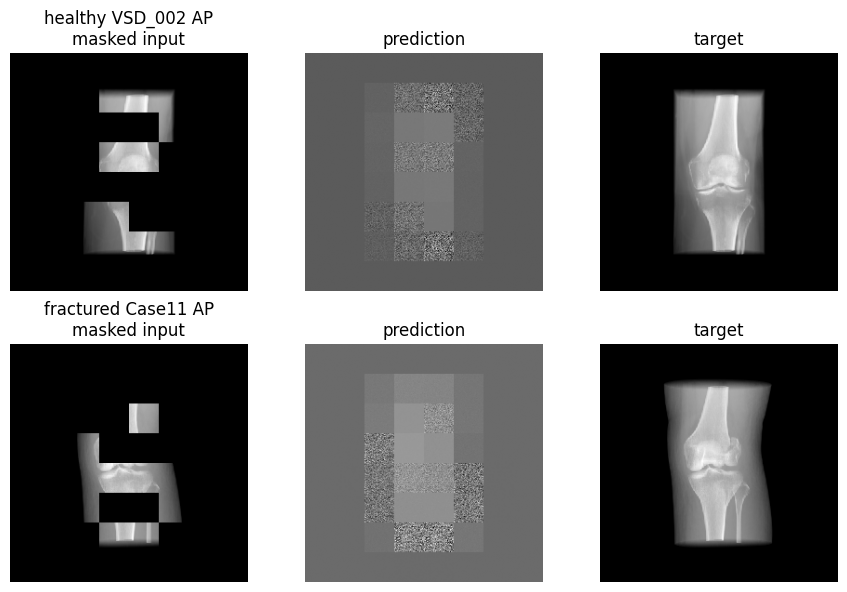

M-8 read: predictions that 'heal' a real fracture line ⇒ shape-prior overfit — raise structure-pixel weight.


In [10]:
# ============================ §2.4a  Monitoring probes (M-5 / M-6 / M-8) ============================

@torch.no_grad()
def pooled_embeddings(enc, df):
    """GAP of the stride-32 features (unmasked) for every ap+lat anchor in df → ([N,768], labels)."""
    ds = FCMAEAnchorDataset(df); enc.eval()
    embs, labels = [], []
    for i in range(len(ds)):
        img, dstag, *_ = ds[i]
        embs.append(_encode_unmasked(enc, img.unsqueeze(0)).mean(dim=(2, 3)).squeeze(0).cpu())
        labels.append(dstag)
    return torch.stack(embs), labels

def effective_rank(emb):
    """exp(entropy of normalized singular values) — dimensional-collapse detector (M-5b)."""
    x = emb - emb.mean(0, keepdim=True)
    s = torch.linalg.svdvals(x)
    p = (s / s.sum().clamp_min(1e-12)).clamp_min(1e-12)
    return float(torch.exp(-(p * p.log()).sum()))

def knn_loo_acc(emb, labels, k=5):
    """Leave-one-out kNN accuracy (cosine) on the cohort label — M-6, eval-only, non-parametric."""
    y = np.array(labels); n = len(y)
    if n <= k or len(set(labels)) < 2:
        return float("nan")
    x = F.normalize(emb, dim=1); sim = (x @ x.t()).numpy(); np.fill_diagonal(sim, -np.inf)
    correct = 0
    for i in range(n):
        nn_idx = np.argsort(-sim[i])[:k]
        vote = pd.Series(y[nn_idx]).mode().iloc[0]
        correct += (vote == y[i])
    return correct / n

if len(monitor_index) >= 2:
    emb_t, lab = pooled_embeddings(fcmae_enc, monitor_index)
    emb_r, _   = pooled_embeddings(imagenet_ref_enc, monitor_index)
    ch_std = emb_t.std(0)
    frac_dead = float((ch_std < 1e-3).float().mean())
    print("M-5a per-channel feature std: "
          f"min={ch_std.min():.4f} med={ch_std.median():.4f} | dead(<1e-3) fraction={frac_dead:.2%} "
          f"{'⚠ collapse — check GRN active / lower LR' if frac_dead > 0.15 else 'ok'}")
    print(f"M-5b effective rank: trained={effective_rank(emb_t):.2f}  imagenet-ref={effective_rank(emb_r):.2f} "
          f"(falling over training ⇒ dimensional collapse)")
    acc_t, acc_r = knn_loo_acc(emb_t, lab), knn_loo_acc(emb_r, lab)
    print(f"M-6 kNN(k=5,cos) cohort acc: trained={acc_t:.3f}  imagenet-ref={acc_r:.3f}  "
          f"→ domain pretraining must beat the reference line (smoke-scale: tiny monitor set, indicative only)")
    try:
        from sklearn.linear_model import LogisticRegression
        Xt = F.normalize(emb_t, dim=1).numpy(); yb = (np.array(lab) == "fractured").astype(int)
        if len(set(yb)) == 2:
            lp = LogisticRegression(max_iter=500).fit(Xt, yb)
            print(f"M-6 linear-probe (in-sample, smoke) acc={lp.score(Xt, yb):.3f} — full-scale uses a held-in fit")
    except Exception as e:
        print(f"M-6 linear-probe skipped ({type(e).__name__}); kNN is the smoke-scale M-6 signal")
else:
    print("M-5/M-6 skipped: monitor set too small at smoke scale")

# --- M-8 visual triptych: masked input / prediction / target, incl. a fractured (irregular) case ----
def assemble(px):
    """[1,1,gh,gw,ph,pw] → [256,256] image."""
    return px[0, 0].permute(0, 2, 1, 3).reshape(IMG_SIZE, IMG_SIZE).cpu().numpy()

def m8_row(ax_in, ax_pred, ax_tgt, enc, dec, img_raw, title):
    mg, sg, _ = build_batch_masks(img_raw); mg = mg.to(device)
    with torch.no_grad():
        pred_n = dec(enc(to_encoder_input(img_raw.to(device)), mg)[-1])       # normalized per-patch pred
    p = img_raw.unfold(2, PATCH, PATCH).unfold(3, PATCH, PATCH)
    mu = p.mean(dim=(-1, -2), keepdim=True); sd = p.std(dim=(-1, -2), keepdim=True).clamp_min(SIGMA_FLOOR)
    pred_px = pred_n.cpu() * sd + mu                                          # denormalize for display
    vis = F.interpolate((~mg).float().cpu(), size=(IMG_SIZE, IMG_SIZE), mode="nearest")[0, 0].numpy()
    ax_in.imshow(img_raw[0, 0].numpy() * vis, cmap="gray");   ax_in.set_title(f"{title}\nmasked input"); ax_in.axis("off")
    ax_pred.imshow(assemble(pred_px), cmap="gray");           ax_pred.set_title("prediction");            ax_pred.axis("off")
    ax_tgt.imshow(img_raw[0, 0].numpy(), cmap="gray");        ax_tgt.set_title("target");                 ax_tgt.axis("off")

_show = {ds: (paired_index[paired_index.dataset == ds].iloc[0] if (paired_index.dataset == ds).any() else None)
         for ds in ["healthy", "fractured"]}
_show = [(ds, r) for ds, r in _show.items() if r is not None]
if _show:
    fig, axes = plt.subplots(len(_show), 3, figsize=(9, 3 * len(_show)), squeeze=False)
    for row, (ds, r) in enumerate(_show):
        img = torch.from_numpy(np.load(r.ap).astype(np.float32)).unsqueeze(0).unsqueeze(0)
        m8_row(axes[row, 0], axes[row, 1], axes[row, 2], fcmae_enc, fcmae_dec, img, f"{ds} {r.case} AP")
    plt.tight_layout(); plt.show()
    print("M-8 read: predictions that 'heal' a real fracture line ⇒ shape-prior overfit — raise structure-pixel weight.")

In [11]:
# ============================ §2.4b  Export & bless (M-10 / L-11) ============================
# Rebuild a FRESH features_only backbone and strict-load the chosen encoder — this proves the exported
# weights are self-consistent and that NO decoder/head parameter can smuggle into the frozen contract
# (L-11). The per-axis-variance + axis-alignment guards (M-10) run in §4 on this blessed checkpoint.
# Downstream (02_frontend_pretrain and beyond) loads convnextv2_fcmae_encoder.pth — the only change
# there is the checkpoint filename; the load mechanism (bare state_dict, strict=False, frozen) and the
# input normalization (mean/std 0.5 — L-6) are unchanged.

BLESSED_STAGE = "P2" if (RUN_P2 and FCMAE_P2_CKPT.exists()) else "P1"
_src_ckpt = FCMAE_P2_CKPT if BLESSED_STAGE == "P2" else FCMAE_P1_CKPT
assert _src_ckpt.exists(), f"no {BLESSED_STAGE} checkpoint to bless — run the stage first"

fresh = make_backbone(pretrained=False)                                    # decoder/heads never constructed here
fresh.load_state_dict(torch.load(_src_ckpt, map_location="cpu"), strict=True)   # raises on any key mismatch
print(f"strict-load OK: blessed encoder = {BLESSED_STAGE} ({_src_ckpt.name})")

FCMAE_CKPT = MODELS_DIR / "convnextv2_fcmae_encoder.pth"
torch.save(fresh.state_dict(), FCMAE_CKPT)                                  # bare state_dict — downstream contract

# config blob (§7.3, L-6): everything downstream / the write-up needs to reproduce this checkpoint
config = dict(
    pretext="FCMAE" + ("+crossview(P2)" if BLESSED_STAGE == "P2" else "(P1)"),
    blessed_stage=BLESSED_STAGE, backbone=BACKBONE, img_size=IMG_SIZE, feat_dims=FEAT_DIMS,
    patch=PATCH, mask_grid=MASK_GRID, mask_ratio=MASK_RATIO, sigma_floor=SIGMA_FLOOR,
    bg_quota=BG_QUOTA, occ_eligible=OCC_ELIGIBLE, struct_weight=STRUCT_WEIGHT,
    lambda_xview=LAMBDA_XVIEW, xview_slack=XVIEW_SLACK,
    channel_adaptation="replicate_1to3",                                   # kept, NOT §2.1's 1ch stem
    input_norm=dict(mean=NORM_MEAN, std=NORM_STD),                         # L-6: frozen so downstream matches
    monitor_split_csv=MONITOR_SPLIT_CSV.name,
    monitor_instances=[f"{d}/{c}/{s}" for d, c, s in sorted(MONITOR_INSTANCES)],
)
with open(FCMAE_CKPT.with_suffix(".config.json"), "w") as f:
    json.dump(config, f, indent=2)
print("saved:", FCMAE_CKPT.name, "+", FCMAE_CKPT.with_suffix(".config.json").name)
print("config:", json.dumps({k: config[k] for k in ["pretext", "mask_ratio", "channel_adaptation"]}))
print("→ §4 re-runs the per-axis-variance + axis-alignment guards (M-10) on this checkpoint before it is trusted.")

strict-load OK: blessed encoder = P2 (convnextv2_fcmae_p2_encoder.pth)


saved: convnextv2_fcmae_encoder.pth + convnextv2_fcmae_encoder.config.json
config: {"pretext": "FCMAE+crossview(P2)", "mask_ratio": 0.6, "channel_adaptation": "replicate_1to3"}
→ §4 re-runs the per-axis-variance + axis-alignment guards (M-10) on this checkpoint before it is trusted.


## 3. Encoder + hybrid bi-planar fusion + orthogonal 2D→3D lift

**Hybrid fusion** drives the 2D feature-viz; the **lift** is what builds the 3D features. Per scale
(`FUSION_TYPES`, fine→coarse):
- `attn` (coarse stages 16²/8²): full cross-attention — *global* AP↔LAT shape correspondence, cheap (≤256 tokens).
- `local` (fine stages 64²/32²): `concat(ap,lat) → 3×3 conv (+ residual)` — preserves *fine-grain local* detail at high resolution without the 4096² attention the reference would incur at 256².

The **2D→3D lift is an orthogonal back-projection** (replacing the reference's extrude-one-map-along-Z,
which made the 3D features constant along depth and capped occupancy Dice ≈ 0.45). Each view keeps the
two volume axes it actually resolves and is broadcast along the axis it does **not** see — AP along A-P
(axis1), LAT along L-R (axis0), both sharing S-I (axis2) — then the two view cubes are fused with a 3D
conv. The cube is ordered `(axis0=L-R, axis1=A-P, axis2=S-I)` to match the GT array. Axis/flip mapping
is resolved empirically (`_axis_probe`) and guarded by Check 2 (per-axis variance) below.
Output: 4 multi-scale **cube** 3D features with channels `[64,128,256,512]` — the decoder contract.

In [12]:
class CrossAttention(nn.Module):
    '''ap (query) attends to lat (key/value). Operates on tokens [B, N, C].'''
    def __init__(self, dim):
        super().__init__()
        self.q = nn.Linear(dim, dim); self.k = nn.Linear(dim, dim); self.v = nn.Linear(dim, dim)
        self.scale = dim ** -0.5
    def forward(self, a, b):
        attn = F.softmax(torch.matmul(self.q(a), self.k(b).transpose(-2, -1)) * self.scale, dim=-1)
        return torch.matmul(attn, self.v(b)) + a            # residual on the query view

class LocalFusion(nn.Module):
    '''Cheap high-res fusion: concat views + 3x3 conv mix, residual on ap.'''
    def __init__(self, dim):
        super().__init__()
        self.mix = nn.Conv2d(2 * dim, dim, kernel_size=3, padding=1)
    def forward(self, a, b):
        return self.mix(torch.cat([a, b], dim=1)) + a       # [B, C, H, W]

# --- bi-planar lift orientation (resolved empirically; see Check 1 / _axis_probe) ---
# GT array axes, from nibabel axcodes ('L','P','S'): axis0 = L-R, axis1 = A-P, axis2 = S-I.
# AP projects along A-P (axis1); LAT projects along L-R (axis0). Both DRR rows (H) = S-I (axis2);
# AP cols (W) = L-R (axis0); LAT cols (W) = A-P (axis1). The fused cube is ordered (axis0, axis1,
# axis2) so it matches the GT array directly. flip_* reverse a row/col direction vs its volume
# axis; locked from the affine + 1-D S-I profile test and re-confirmed by the one-sample overfit
# guard in the smoke test (a mis-flip cannot overfit a single volume).
LIFT_FLIP_SI      = False   # DRR rows  vs axis2 (S-I)
LIFT_FLIP_AP_COL  = False   # AP  cols  vs axis0 (L-R)
LIFT_FLIP_LAT_COL = True    # LAT cols  vs axis1 (A-P)

class BiPlanarFeatureFusion(nn.Module):
    def __init__(self, feat_dims=FEAT_DIMS, out_channels=OUT_CHANNELS,
                 fusion_types=FUSION_TYPES, depth=DEPTH, pretrained=PRETRAINED,
                 freeze_encoder=FREEZE_ENCODER):
        super().__init__()
        self.encoder = make_backbone(pretrained)
        self.fusion_types = list(fusion_types)
        self.depth = depth   # retained for signature compat; the orthogonal lift no longer uses it
        self.fuse = nn.ModuleList([
            CrossAttention(d) if t == "attn" else LocalFusion(d)
            for d, t in zip(feat_dims, fusion_types)])
        self.to3d = nn.ModuleList([nn.Conv2d(c, o, 1) for c, o in zip(feat_dims, out_channels)])
        # expand3d fuses the two orthogonally back-projected view cubes (2*o -> o) in 3D
        self.expand3d = nn.ModuleList([nn.Conv3d(2 * o, o, 3, padding=1) for o in out_channels])
        if freeze_encoder:
            for p in self.encoder.parameters(): p.requires_grad = False

    def load_pretrained_encoder(self, path):
        '''Load a bare encoder state_dict (SimCLR-era or the FCMAE blessed checkpoint) into the SAME
        features_only ConvNeXtV2 backbone. missing=0 expected — the export writes matching keys.'''
        missing, unexpected = self.encoder.load_state_dict(torch.load(path, map_location="cpu"),
                                                            strict=False)
        print(f"loaded pretrained encoder from {Path(path).name}: missing={len(missing)} unexpected={len(unexpected)}")
        return missing, unexpected

    def _ortho_lift(self, ap_f, lat_f, c2d, c3d):
        '''Orthogonal back-projection lift. Each view is placed on the two volume axes it actually
        resolves and broadcast along its (unobserved) projection axis; the two view cubes are then
        fused in 3D. This preserves bi-planar depth instead of extruding one fused 2D map along Z.
        Output cube is ordered (axis0=L-R, axis1=A-P, axis2=S-I) to match the GT array.'''
        B, C, H, W = ap_f.shape           # square feature map at this level: S = H = W
        S = H
        ap = c2d(ap_f); lat = c2d(lat_f)  # shared 1x1 projection -> [B, O, H, W] each
        O = ap.shape[1]
        if LIFT_FLIP_SI:      ap = ap.flip(2); lat = lat.flip(2)   # rows (H) = S-I (axis2)
        if LIFT_FLIP_AP_COL:  ap = ap.flip(3)                       # AP  cols (W) = L-R (axis0)
        if LIFT_FLIP_LAT_COL: lat = lat.flip(3)                     # LAT cols (W) = A-P (axis1)
        # AP: (H=axis2, W=axis0) -> cube (axis0, axis1, axis2), broadcast over axis1 (A-P)
        ap_cube = ap.permute(0, 1, 3, 2).unsqueeze(3).expand(B, O, S, S, S)
        # LAT: (H=axis2, W=axis1) -> cube (axis0, axis1, axis2), broadcast over axis0 (L-R)
        lat_cube = lat.permute(0, 1, 3, 2).unsqueeze(2).expand(B, O, S, S, S)
        return c3d(torch.cat([ap_cube, lat_cube], dim=1))           # [B, O, S, S, S]

    def forward(self, ap_img, lat_img):
        ap_feats, lat_feats = self.encoder(ap_img), self.encoder(lat_img)
        fused2d, fused3d = [], []
        for ap_f, lat_f, fuse, c2d, c3d, t in zip(
            ap_feats, lat_feats, self.fuse, self.to3d, self.expand3d, self.fusion_types):
            B, C, H, W = ap_f.shape
            if t == "attn":
                a = ap_f.flatten(2).transpose(1, 2); b = lat_f.flatten(2).transpose(1, 2)
                f2d = fuse(a, b).transpose(1, 2).reshape(B, C, H, W)
            else:
                f2d = fuse(ap_f, lat_f)
            fused2d.append(f2d)                                  # kept only for the feature-viz cells
            fused3d.append(self._ortho_lift(ap_f, lat_f, c2d, c3d))
        return fused2d, fused3d

## 4. 3D feature smoke test + visual QA

Forward one **healthy** and one **fractured** real DRR pair; assert the four 3D feature shapes
match the decoder contract; then visualize inputs + a few fused feature channels.

In [13]:
fusion = BiPlanarFeatureFusion().to(device).eval()
# Load the blessed FCMAE encoder (M-10): the fusion backbone is the SAME features_only ConvNeXtV2, so
# the bare state_dict loads with missing=0. This cell IS the export-time guard re-run (§2.4b).
ckpt = MODELS_DIR / "convnextv2_fcmae_encoder.pth"
if ckpt.exists():
    missing, unexpected = fusion.load_pretrained_encoder(ckpt)
    assert len(missing) == 0, f"M-10: blessed encoder did not load cleanly (missing={len(missing)})"
else:
    print("[warn] no blessed FCMAE checkpoint yet — run §2 first; using current encoder weights")

def first_pair(df, dataset):
    sub = df[df.dataset == dataset]
    return sub.iloc[0] if len(sub) else None

# orthogonal lift -> CUBE features: depth == height == width == IMG_SIZE//stride at each level
expected = [(c, IMG_SIZE // s) for c, s in zip(OUT_CHANNELS, [4, 8, 16, 32])]  # (channels, side)
samples = {ds: first_pair(paired_index, ds) for ds in ["healthy", "fractured"]}

f3d = None
for ds, r in samples.items():
    if r is None:
        print(f"[skip] no {ds} pair found"); continue
    ap = paired_tf(load_drr(r.ap)).unsqueeze(0).to(device)
    lat = paired_tf(load_drr(r.lat)).unsqueeze(0).to(device)
    with torch.no_grad():
        _, f3d = fusion(ap, lat)
    print(f"\n{ds}: {r.case} {r.side} ({r.variant})")
    for i, (f, (ec, es)) in enumerate(zip(f3d, expected)):
        B, C, D, H, W = f.shape
        ok = (C == ec and D == es and H == es and W == es)
        print(f"  level{i}: {tuple(f.shape)}  expect C={ec}, DxHxW={es}^3  {'OK' if ok else 'MISMATCH'}")
        assert ok, f"feature {i} shape mismatch (expected cube {es}^3)"
print("\nAll 3D feature shapes match the decoder contract (cube features).")

# --- Check 2 / M-10: per-axis feature variance (extrusion detector) ------------------------------
# The reference lift broadcast one fused 2D map along depth -> std==0 along that axis (the bug that
# capped Dice ~0.45). The orthogonal lift must vary along ALL THREE spatial axes. FAIL loudly if any
# axis collapses, so a regression to an extruding lift — or a bad pretrained encoder — cannot pass
# silently. Run on the blessed FCMAE weights, this is the export-time M-10 guard.
print("\nCheck 2 (M-10) — per-axis feature std (mean over batch,channel); every axis must be > 1e-4:")
assert f3d is not None, "no features produced; cannot run Check 2"
for i, f in enumerate(f3d):
    s0 = f.std(dim=2).mean().item()   # along axis0 (L-R)
    s1 = f.std(dim=3).mean().item()   # along axis1 (A-P)
    s2 = f.std(dim=4).mean().item()   # along axis2 (S-I)
    ok = min(s0, s1, s2) > 1e-4
    print(f"  level{i}: std[axis0]={s0:.4f} std[axis1]={s1:.4f} std[axis2]={s2:.4f}  "
          f"{'OK' if ok else 'FAIL — axis collapsed (extrusion bug!)'}")
    assert ok, f"level{i} collapses along an axis — the lift is extruding, not back-projecting"
print("Check 2 (M-10) PASS: 3D features vary on all three axes (no extrusion); blessed encoder OK.")

loaded pretrained encoder from convnextv2_fcmae_encoder.pth: missing=0 unexpected=0



healthy: VSD_002 left (normal)
  level0: (1, 64, 64, 64, 64)  expect C=64, DxHxW=64^3  OK
  level1: (1, 128, 32, 32, 32)  expect C=128, DxHxW=32^3  OK
  level2: (1, 256, 16, 16, 16)  expect C=256, DxHxW=16^3  OK
  level3: (1, 512, 8, 8, 8)  expect C=512, DxHxW=8^3  OK



fractured: Case11 right (normal)
  level0: (1, 64, 64, 64, 64)  expect C=64, DxHxW=64^3  OK
  level1: (1, 128, 32, 32, 32)  expect C=128, DxHxW=32^3  OK
  level2: (1, 256, 16, 16, 16)  expect C=256, DxHxW=16^3  OK
  level3: (1, 512, 8, 8, 8)  expect C=512, DxHxW=8^3  OK

All 3D feature shapes match the decoder contract (cube features).

Check 2 (M-10) — per-axis feature std (mean over batch,channel); every axis must be > 1e-4:


  level0: std[axis0]=0.1046 std[axis1]=0.0973 std[axis2]=0.1205  OK
  level1: std[axis0]=0.2690 std[axis1]=0.2951 std[axis2]=0.2914  OK
  level2: std[axis0]=3.2557 std[axis1]=3.3521 std[axis2]=3.2924  OK
  level3: std[axis0]=0.6436 std[axis1]=0.6335 std[axis2]=0.7646  OK
Check 2 (M-10) PASS: 3D features vary on all three axes (no extrusion); blessed encoder OK.


finest stage tokens: 4096  | all-attn matrix/sample: 16,777,216 floats (~67 MB fp32)  -> hybrid uses conv here instead.


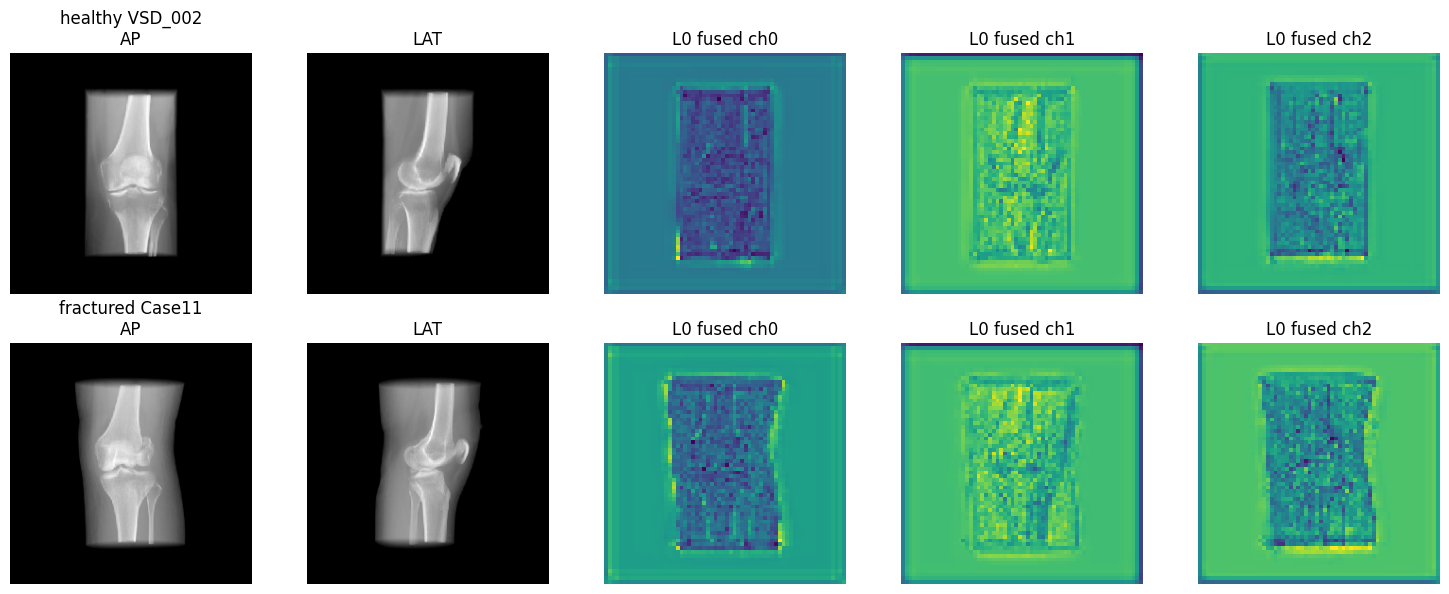

In [14]:
# --- memory note: hybrid vs all-attention fusion at 256^2 (finest stage = 64x64 = 4096 tokens) ---
n_fine = (IMG_SIZE // 4) ** 2
print(f"finest stage tokens: {n_fine}  | all-attn matrix/sample: {n_fine**2:,} floats "
      f"(~{n_fine**2*4/1e6:.0f} MB fp32)  -> hybrid uses conv here instead.")

# --- visual QA: inputs + a few fused feature channels (level 0, the high-res local features) ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for row, (ds, r) in enumerate(samples.items()):
    if r is None: continue
    ap = paired_tf(load_drr(r.ap)).unsqueeze(0).to(device)
    lat = paired_tf(load_drr(r.lat)).unsqueeze(0).to(device)
    with torch.no_grad():
        f2d, _ = fusion(ap, lat)
    axes[row, 0].imshow(load_drr(r.ap)[0], cmap="gray"); axes[row, 0].set_title(f"{ds} {r.case}\nAP")
    axes[row, 1].imshow(load_drr(r.lat)[0], cmap="gray"); axes[row, 1].set_title("LAT")
    fmap = f2d[0][0].cpu()   # level-0 fused features [C,64,64]
    for j in range(3):
        axes[row, 2 + j].imshow(fmap[j], cmap="viridis"); axes[row, 2 + j].set_title(f"L0 fused ch{j}")
    for ax in axes[row]: ax.axis("off")
plt.tight_layout(); plt.show()

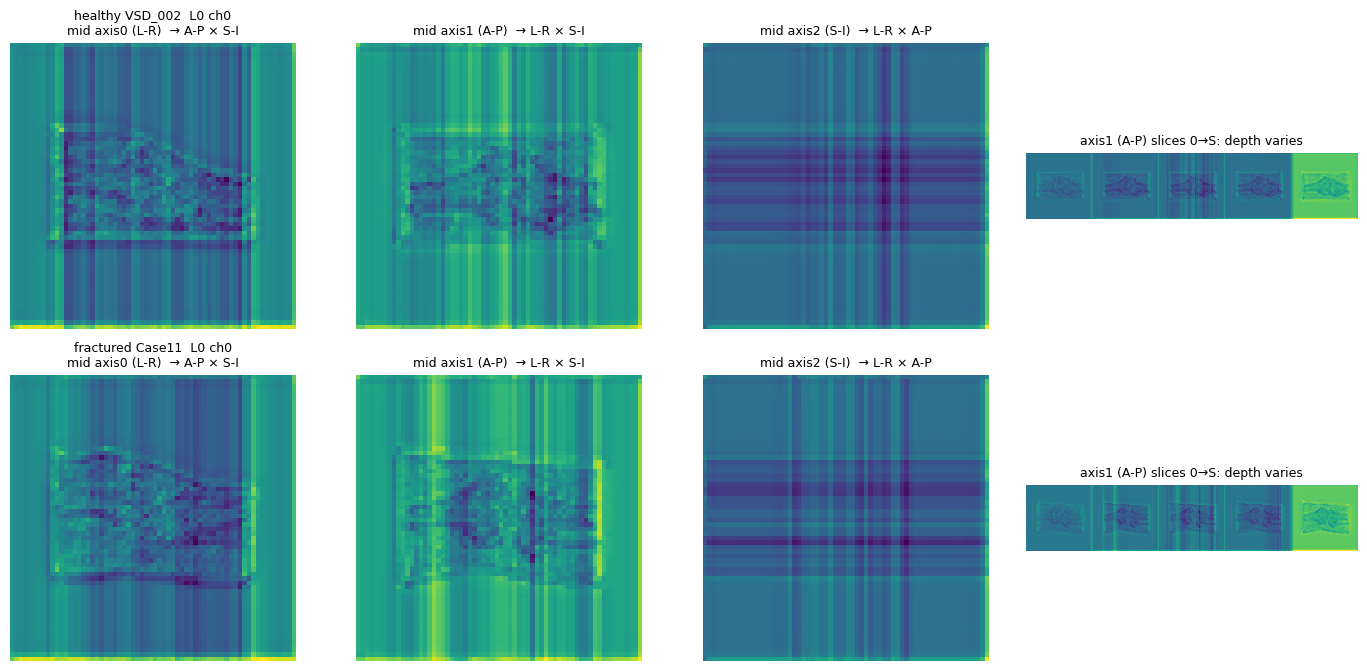

If any mid-plane is a flat band, or the axis1 montage frames are identical, the lift is extruding (Check 2 would also FAIL). Distinct, structured planes = a true depth-varying cube.


In [15]:
# --- 3D feature visual check: orthogonal mid-slices of the LIFTED 3D volume (visible non-extrusion) ---
# Check 2 asserts per-axis variance numerically; this SHOWS it. For a representative level+channel, we
# slice the cube through its three mid-planes — if the lift were still extruding, one plane would be a
# flat band (constant along the collapsed axis). A short montage steps along axis1 (A-P, the depth AP
# cannot see) to confirm the volume genuinely varies through depth. Run on the blessed FCMAE weights.
VIZ_LEVEL, VIZ_CH = 0, 0                                    # level-0 cube = 64^3
fig, axes = plt.subplots(len(samples), 4, figsize=(14, 3.4 * len(samples)), squeeze=False)
for row, (ds, r) in enumerate(samples.items()):
    if r is None:
        for ax in axes[row]: ax.axis("off")
        continue
    ap = paired_tf(load_drr(r.ap)).unsqueeze(0).to(device)
    lat = paired_tf(load_drr(r.lat)).unsqueeze(0).to(device)
    with torch.no_grad():
        _, f3 = fusion(ap, lat)
    vol = f3[VIZ_LEVEL][0, VIZ_CH].cpu()                    # [S,S,S] = (axis0 L-R, axis1 A-P, axis2 S-I)
    S = vol.shape[0]; mid = S // 2
    panels = [
        (vol[mid, :, :], f"{ds} {r.case}  L{VIZ_LEVEL} ch{VIZ_CH}\nmid axis0 (L-R)  → A-P × S-I"),
        (vol[:, mid, :], "mid axis1 (A-P)  → L-R × S-I"),
        (vol[:, :, mid], "mid axis2 (S-I)  → L-R × A-P"),
    ]
    for j, (img, ttl) in enumerate(panels):
        axes[row, j].imshow(img, cmap="viridis"); axes[row, j].set_title(ttl, fontsize=9); axes[row, j].axis("off")
    # montage: 5 slices stepping along axis1 (A-P depth) tiled horizontally — must not be identical frames
    steps = torch.linspace(0, S - 1, 5).round().long()
    montage = torch.cat([vol[:, k, :] for k in steps], dim=1)
    axes[row, 3].imshow(montage, cmap="viridis")
    axes[row, 3].set_title("axis1 (A-P) slices 0→S: depth varies", fontsize=9); axes[row, 3].axis("off")
plt.tight_layout(); plt.show()
print("If any mid-plane is a flat band, or the axis1 montage frames are identical, the lift is extruding "
      "(Check 2 would also FAIL). Distinct, structured planes = a true depth-varying cube.")

## 5. Deferred work (documented, not built here)

This notebook stops at reusable 3D features. The next stages:

1. **Decoder + supervised training** — attach a 3D U-Net and a V-Net to `fused3d` and train with the
   **same** loss (BCE+Dice, now multi-channel over the 4 bones), so only the decoder differs (the
   baseline comparison). See `02_frontend_pretrain.ipynb` (front-end freeze) then `03_decoder_pipeline.ipynb`.
2. **GT per-bone occupancy** — load the 4-channel STL-derived masks from
   `data/interim/gt_per_bone_256/{dataset}/{key}/{key}_{bone}.nii.gz` (femur/tibia/patella/fibula,
   built by `00_gt_per_bone.ipynb`); resample each bone to the decoder output grid and pair via
   `(dataset,case,side)`. This replaces the earlier `predrr > threshold` binary occupancy target
   (density-confounded on dim-CT bone).
3. **Geometric augmentation** — for rows with `geometric=True` (rotation≠0 or flip), apply the *same*
   transform to the 3D GT before the loss; photometric-only rows pair with the unmodified GT.
4. **Joint fine-tuning** — unfreeze the encoder (already `FREEZE_ENCODER=False`) and fine-tune end-to-end.
5. **HPC scale-up** — full FCMAE **P1→P2 curriculum** on GPU (256², warmup→cosine, 100–400 epochs,
   early-stop on the monitor loss), mirrored in `HPC/HPC_notebooks/modeling_HPC/01_encoder_pipeline.ipynb`
   (POSIX paths). Then the **Gate G4** four-way downstream comparison — FCMAE-P2 / FCMAE-P1 /
   ImageNet-FCMAE-only / random-init, split by cohort — decides which pretraining (or none) ships.